part a: training with sparse reward...
episode 200, avg reward: 50.00, success rate: 100.00%, epsilon: 0.367
episode 400, avg reward: 50.00, success rate: 100.00%, epsilon: 0.135
episode 600, avg reward: 50.00, success rate: 100.00%, epsilon: 0.049
episode 800, avg reward: 50.00, success rate: 100.00%, epsilon: 0.018
episode 1000, avg reward: 50.00, success rate: 100.00%, epsilon: 0.010

part a: training with shaped reward...
episode 200, avg reward: 31.55, success rate: 8.00%, epsilon: 0.367
episode 400, avg reward: 39.80, success rate: 52.00%, epsilon: 0.135
episode 600, avg reward: 40.97, success rate: 71.00%, epsilon: 0.049
episode 800, avg reward: 41.64, success rate: 92.00%, epsilon: 0.018
episode 1000, avg reward: 41.70, success rate: 97.00%, epsilon: 0.010


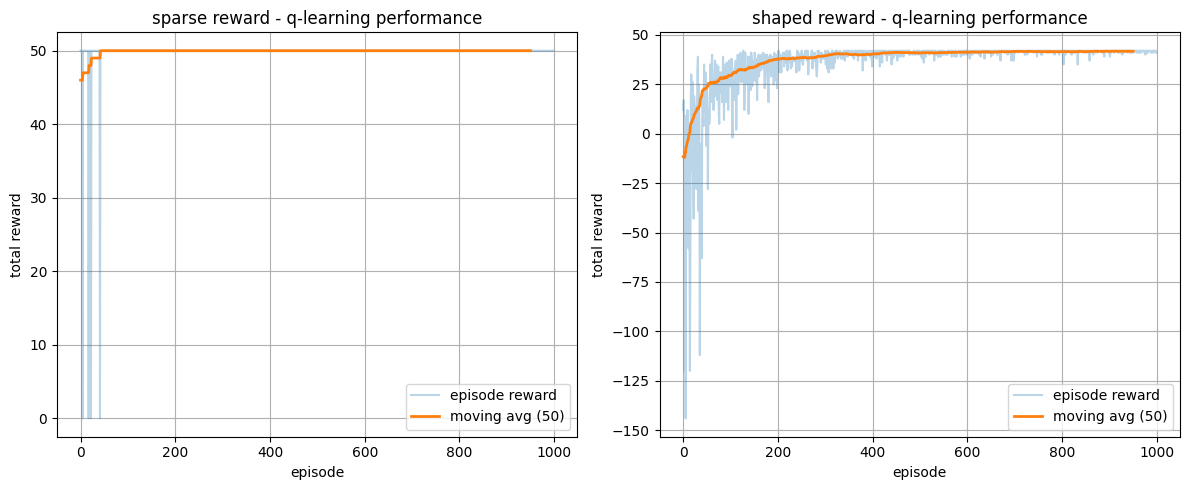


part b: training with adaptive wind...
episode 200, avg reward: 32.53, success rate: 8.00%, epsilon: 0.367
episode 400, avg reward: 39.76, success rate: 46.00%, epsilon: 0.135
episode 600, avg reward: 41.27, success rate: 77.00%, epsilon: 0.049
episode 800, avg reward: 41.92, success rate: 96.00%, epsilon: 0.018
episode 1000, avg reward: 41.94, success rate: 96.00%, epsilon: 0.010


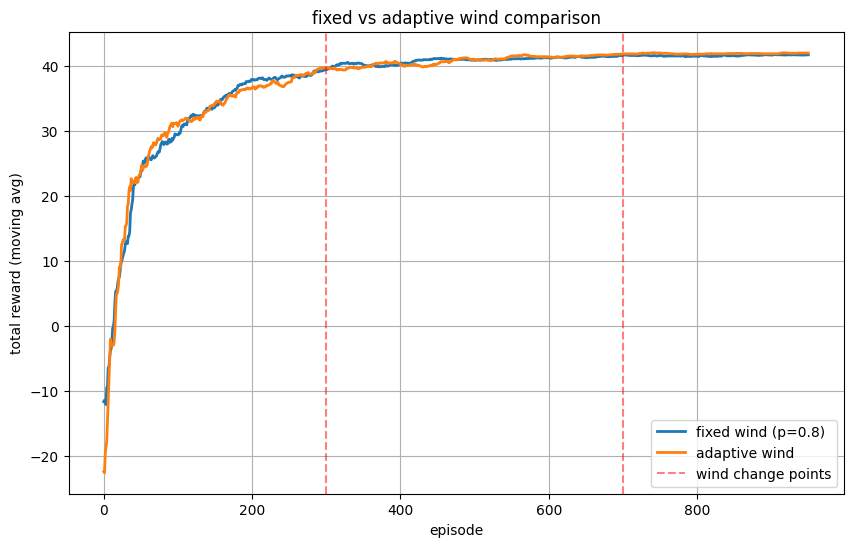


part b: training with energy constraint...
episode 200, avg reward: 25.88, success rate: 31.00%, epsilon: 0.367
episode 400, avg reward: 40.69, success rate: 74.00%, epsilon: 0.135
episode 600, avg reward: 43.47, success rate: 83.00%, epsilon: 0.049
episode 800, avg reward: 43.28, success rate: 86.00%, epsilon: 0.018
episode 1000, avg reward: 43.54, success rate: 85.00%, epsilon: 0.010


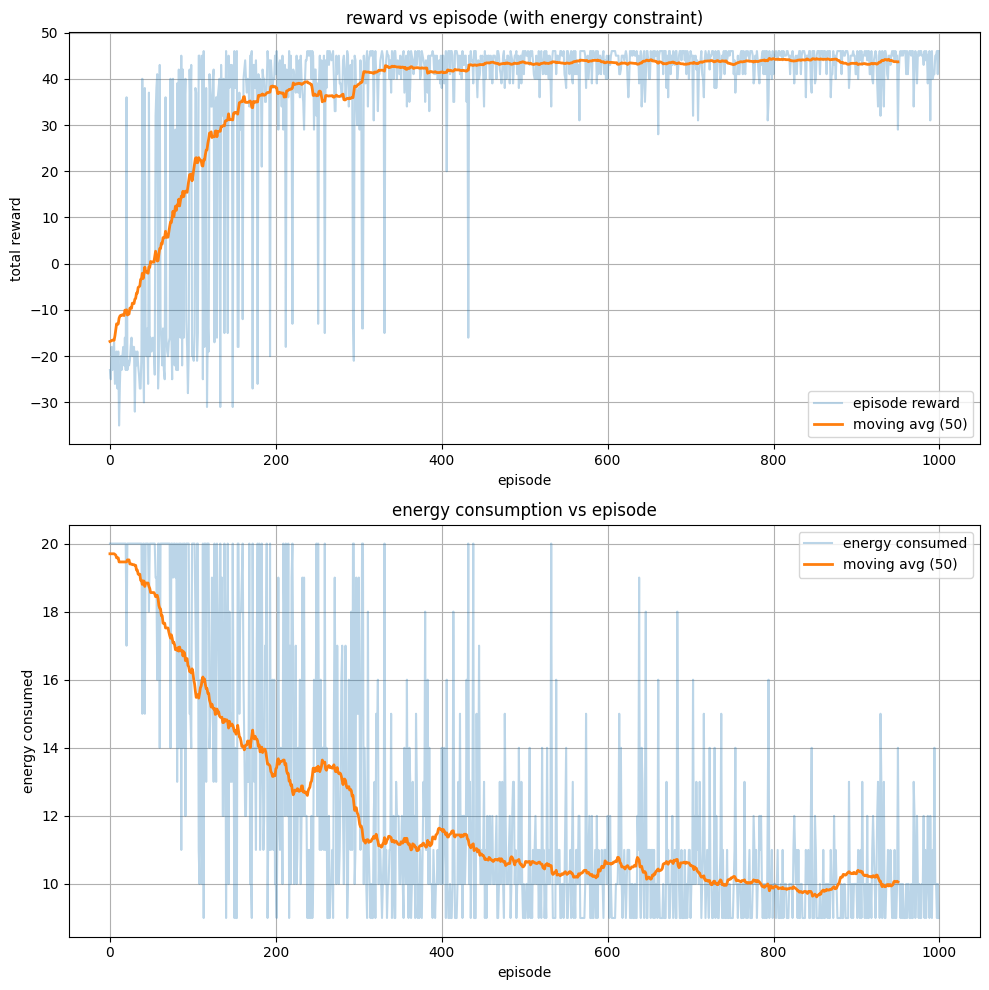


part b: training with distance-based reward...
episode 200, avg reward: 40.57, success rate: 62.00%, epsilon: 0.367
episode 400, avg reward: 44.55, success rate: 99.00%, epsilon: 0.135
episode 600, avg reward: 45.00, success rate: 100.00%, epsilon: 0.049
episode 800, avg reward: 45.34, success rate: 100.00%, epsilon: 0.018
episode 1000, avg reward: 45.47, success rate: 100.00%, epsilon: 0.010


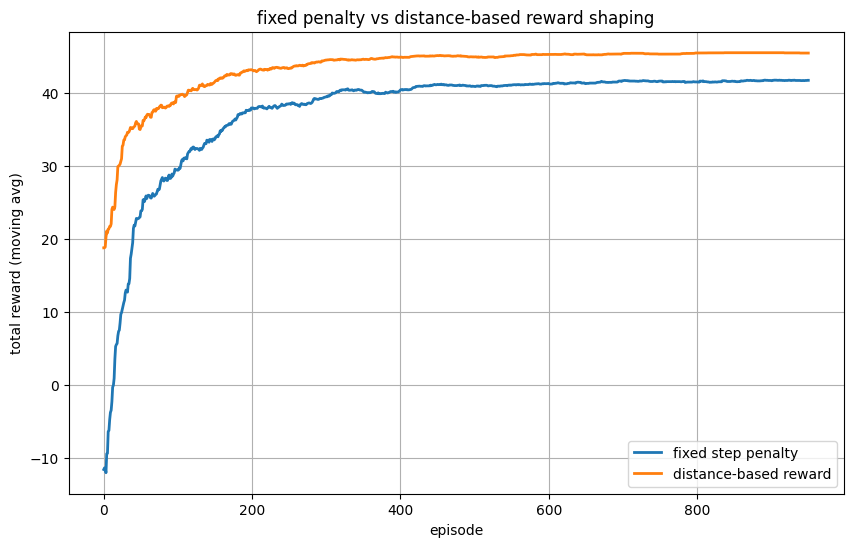


all training complete. plots saved.

convergence analysis:
sparse reward - final avg reward: 50.00
shaped reward - final avg reward: 41.70
adaptive wind - final avg reward: 41.94
energy constraint - final avg reward: 43.54
distance-based - final avg reward: 45.47


In [1]:
import numpy as np
import gymnasium as gym
from gymnasium import Env, spaces
import matplotlib.pyplot as plt

class StochasticWindyGridWorld(Env):
    def __init__(self, rows=6, cols=6, wind_prob=0.8, energy_mode=False):
        super(StochasticWindyGridWorld, self).__init__()

        self.rows = rows
        self.cols = cols
        self.wind_prob = wind_prob
        self.energy_mode = energy_mode

        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Discrete(rows * cols)

        #define positions
        self.start_pos = (5, 0)
        self.goal_pos = (0, 5)
        self.obstacle_positions = [(2, 2), (2, 3), (3, 2), (3, 3)]

        #wind configuration - stronger wind
        self.wind_strength = {0: 0, 1: 0, 2: 1, 3: 1, 4: 2, 5: 2}

        self.agent_pos = None
        self.energy = 20 if energy_mode else None

    def reset(self):
        self.agent_pos = list(self.start_pos)
        if self.energy_mode:
            self.energy = 20
        return self._get_state()

    def _get_state(self):
        return self.agent_pos[0] * self.cols + self.agent_pos[1]

    def _apply_wind(self):
        col = self.agent_pos[1]
        wind_str = self.wind_strength.get(col, 0)

        if wind_str > 0 and np.random.random() < self.wind_prob:
            self.agent_pos[0] = max(0, self.agent_pos[0] - wind_str)
            return wind_str
        return 0

    def step(self, action):
        reward = 0
        done = False
        hit_obstacle = False

        new_pos = self.agent_pos.copy()

        if action == 0:
            new_pos[1] -= 1
        elif action == 1:
            new_pos[1] += 1
        elif action == 2:
            new_pos[0] -= 1
        elif action == 3:
            new_pos[0] += 1

        #check boundaries
        if (new_pos[0] < 0 or new_pos[0] >= self.rows or
            new_pos[1] < 0 or new_pos[1] >= self.cols):
            new_pos = self.agent_pos.copy()
        #check obstacles
        elif tuple(new_pos) in self.obstacle_positions:
            new_pos = self.agent_pos.copy()
            hit_obstacle = True
        else:
            self.agent_pos = new_pos

        #energy consumption for movement
        if self.energy_mode:
            self.energy -= 1

        #apply wind after movement
        wind_applied = self._apply_wind()
        if self.energy_mode and wind_applied > 0:
            self.energy -= 1

        #check goal
        if tuple(self.agent_pos) == self.goal_pos:
            reward = 50
            done = True

        #energy termination
        if self.energy_mode and self.energy <= 0:
            done = True

        return self._get_state(), reward, done, {'energy': self.energy if self.energy_mode else None, 'hit_obstacle': hit_obstacle}

class ShapedWindyGridWorld(StochasticWindyGridWorld):
    def __init__(self, rows=6, cols=6, wind_prob=0.8, energy_mode=False, distance_based=False):
        super().__init__(rows, cols, wind_prob, energy_mode)
        self.distance_based = distance_based

    def step(self, action):
        state, base_reward, done, info = super().step(action)

        if not done:
            if self.distance_based:
                #distance-based reward
                dist = abs(self.agent_pos[0] - self.goal_pos[0]) + abs(self.agent_pos[1] - self.goal_pos[1])
                base_reward = -0.1 * dist
            else:
                #fixed step penalty
                base_reward = -1

                #obstacle collision penalty
                if info['hit_obstacle']:
                    base_reward = -5

        return state, base_reward, done, info

def q_learning(env, episodes=1000, alpha=0.1, gamma=0.99, epsilon=1.0,
               epsilon_min=0.01, epsilon_decay=0.995, adaptive_wind=False):

    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    rewards_per_episode = []
    energy_per_episode = []

    for episode in range(episodes):
        #adaptive wind probability
        if adaptive_wind:
            if episode < 300:
                env.wind_prob = 0.6
            elif episode < 700:
                env.wind_prob = 0.8
            else:
                env.wind_prob = 0.9

        state = env.reset()
        total_reward = 0
        done = False
        steps = 0
        max_steps = 100  #strict step limit

        while not done and steps < max_steps:
            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q_table[state])

            next_state, reward, done, info = env.step(action)
            total_reward += reward
            steps += 1

            q_table[state, action] = q_table[state, action] + alpha * (
                reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
            )

            state = next_state

        #no penalty for timeout - just record actual reward

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_per_episode.append(total_reward)

        if info.get('energy') is not None:
            energy_consumed = 20 - info['energy'] if info['energy'] > 0 else 20
        else:
            energy_consumed = steps
        energy_per_episode.append(energy_consumed)

        if (episode + 1) % 200 == 0:
            avg_reward = np.mean(rewards_per_episode[-100:])
            success_rate = sum(1 for r in rewards_per_episode[-100:] if r > 40) / 100
            print(f"episode {episode + 1}, avg reward: {avg_reward:.2f}, success rate: {success_rate:.2%}, epsilon: {epsilon:.3f}")

    return q_table, rewards_per_episode, energy_per_episode

#set random seed for reproducibility
np.random.seed(123)  #different seed

#part a: sparse reward
print("part a: training with sparse reward...")
env_sparse = StochasticWindyGridWorld()
q_table_sparse, rewards_sparse, _ = q_learning(env_sparse, episodes=1000)

#part a: shaped reward
print("\npart a: training with shaped reward...")
env_shaped = ShapedWindyGridWorld()
q_table_shaped, rewards_shaped, _ = q_learning(env_shaped, episodes=1000)

#part a: plot comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(rewards_sparse, alpha=0.3, label='episode reward')
plt.plot(np.convolve(rewards_sparse, np.ones(50)/50, mode='valid'), linewidth=2, label='moving avg (50)')
plt.xlabel('episode')
plt.ylabel('total reward')
plt.title('sparse reward - q-learning performance')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(rewards_shaped, alpha=0.3, label='episode reward')
plt.plot(np.convolve(rewards_shaped, np.ones(50)/50, mode='valid'), linewidth=2, label='moving avg (50)')
plt.xlabel('episode')
plt.ylabel('total reward')
plt.title('shaped reward - q-learning performance')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('part_a_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

#part b: adaptive wind
print("\npart b: training with adaptive wind...")
env_adaptive = ShapedWindyGridWorld()
q_table_adaptive, rewards_adaptive, _ = q_learning(env_adaptive, episodes=1000, adaptive_wind=True)

#part b: fixed vs adaptive wind comparison
plt.figure(figsize=(10, 6))
plt.plot(np.convolve(rewards_shaped, np.ones(50)/50, mode='valid'), linewidth=2, label='fixed wind (p=0.8)')
plt.plot(np.convolve(rewards_adaptive, np.ones(50)/50, mode='valid'), linewidth=2, label='adaptive wind')
plt.axvline(x=300, color='r', linestyle='--', alpha=0.5, label='wind change points')
plt.axvline(x=700, color='r', linestyle='--', alpha=0.5)
plt.xlabel('episode')
plt.ylabel('total reward (moving avg)')
plt.title('fixed vs adaptive wind comparison')
plt.legend()
plt.grid(True)
plt.savefig('part_b_adaptive_wind.png', dpi=300, bbox_inches='tight')
plt.show()

#part b: energy constraint
print("\npart b: training with energy constraint...")
env_energy = ShapedWindyGridWorld(energy_mode=True)
q_table_energy, rewards_energy, energy_consumption = q_learning(env_energy, episodes=1000)

#part b: energy constraint plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

ax1.plot(rewards_energy, alpha=0.3, label='episode reward')
ax1.plot(np.convolve(rewards_energy, np.ones(50)/50, mode='valid'), linewidth=2, label='moving avg (50)')
ax1.set_xlabel('episode')
ax1.set_ylabel('total reward')
ax1.set_title('reward vs episode (with energy constraint)')
ax1.legend()
ax1.grid(True)

ax2.plot(energy_consumption, alpha=0.3, label='energy consumed')
ax2.plot(np.convolve(energy_consumption, np.ones(50)/50, mode='valid'), linewidth=2, label='moving avg (50)')
ax2.set_xlabel('episode')
ax2.set_ylabel('energy consumed')
ax2.set_title('energy consumption vs episode')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('part_b_energy_constraint.png', dpi=300, bbox_inches='tight')
plt.show()

#part b: distance-based reward shaping
print("\npart b: training with distance-based reward...")
env_distance = ShapedWindyGridWorld(distance_based=True)
q_table_distance, rewards_distance, _ = q_learning(env_distance, episodes=1000)

#part b: distance-based vs fixed penalty comparison
plt.figure(figsize=(10, 6))
plt.plot(np.convolve(rewards_shaped, np.ones(50)/50, mode='valid'), linewidth=2, label='fixed step penalty')
plt.plot(np.convolve(rewards_distance, np.ones(50)/50, mode='valid'), linewidth=2, label='distance-based reward')
plt.xlabel('episode')
plt.ylabel('total reward (moving avg)')
plt.title('fixed penalty vs distance-based reward shaping')
plt.legend()
plt.grid(True)
plt.savefig('part_b_distance_based.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nall training complete. plots saved.")
print("\nconvergence analysis:")
print(f"sparse reward - final avg reward: {np.mean(rewards_sparse[-100:]):.2f}")
print(f"shaped reward - final avg reward: {np.mean(rewards_shaped[-100:]):.2f}")
print(f"adaptive wind - final avg reward: {np.mean(rewards_adaptive[-100:]):.2f}")
print(f"energy constraint - final avg reward: {np.mean(rewards_energy[-100:]):.2f}")
print(f"distance-based - final avg reward: {np.mean(rewards_distance[-100:]):.2f}")